# Car Rental Transformed Analytics
This notebook performs 20 practical transformation scenarios on `car_rental_cleaned_dataset.csv`.

Notes:
- Some use-cases (scheduled SLA, add-ons, subscription) are not directly available in source columns, so lightweight, clearly-labeled proxy assumptions are used.
- The focus is simple, reproducible transformation logic using pandas/numpy with quick visuals via matplotlib/seaborn.


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

df = pd.read_csv("../Datasets/car_rental_cleaned_dataset.csv")

required_defaults = {
    "Reservation_ID": "",
    "Customer_ID": "",
    "Vehicle_ID": "",
    "Vehicle_Class": "Unknown",
    "Booking_Status": "Unknown",
    "Booking_TS": pd.NaT,
    "Pickup_TS": pd.NaT,
    "Return_TS": pd.NaT,
    "Odo_Start": np.nan,
    "Odo_End": np.nan,
    "Fuel_Level": np.nan,
    "Rate": np.nan,
    "Promo_Code": "",
    "City": "Unknown",
    "GPS_Lat": np.nan,
    "GPS_Lon": np.nan,
    "Speed": np.nan,
    "Damage_Flag": "None",
    "Notes": "",
    "Vehicle_ID_Invalid": False,
    "Duration_Hours": np.nan,
    "Distance_Driven": np.nan,
    "Refuel_Event": "",
    "Driver_Behavior": "Unknown",
    "Total_Amount": np.nan,
}
for col, default in required_defaults.items():
    if col not in df.columns:
        df[col] = default

for col in ["Booking_TS", "Pickup_TS", "Return_TS", "Prev_Return", "Promo_Expiry"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

for col in ["Duration_Hours", "Distance_Driven", "Odo_Start", "Odo_End", "Rate", "Total_Amount", "Fuel_Level", "Speed", "GPS_Lat", "GPS_Lon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_values = df["Vehicle_ID_Invalid"].astype(str).str.lower().str.strip()
df["vehicle_id_invalid_flag"] = bool_values.isin(["true", "1", "yes"])

df["is_completed"] = df["Booking_Status"].eq("Completed")
df["rental_hours"] = df["Duration_Hours"]
mask_missing_hours = df["rental_hours"].isna() & df["Pickup_TS"].notna() & df["Return_TS"].notna()
df.loc[mask_missing_hours, "rental_hours"] = (
    (df.loc[mask_missing_hours, "Return_TS"] - df.loc[mask_missing_hours, "Pickup_TS"]).dt.total_seconds() / 3600
)
df["rental_hours"] = df["rental_hours"].clip(lower=0)

df["distance_km"] = df["Distance_Driven"].clip(lower=0)
df["lead_time_hours"] = ((df["Pickup_TS"] - df["Booking_TS"]).dt.total_seconds() / 3600).clip(lower=0)
df["booking_month"] = df["Booking_TS"].dt.to_period("M").astype(str)
df["pickup_date"] = df["Pickup_TS"].dt.date

a_start = df["Pickup_TS"].min()
a_end = df["Return_TS"].max()
analysis_hours = max((a_end - a_start).total_seconds() / 3600, 1) if pd.notna(a_start) and pd.notna(a_end) else 1

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Analysis window hours: {analysis_hours:,.2f}")
print(df[["Reservation_ID", "City", "Vehicle_Class", "Booking_Status", "rental_hours", "distance_km", "Rate", "Total_Amount"]].head())


Rows: 4,527 | Columns: 38
Analysis window hours: 8,159.15
  Reservation_ID     City Vehicle_Class Booking_Status  rental_hours  \
0      RES-00003    Delhi        Suzuki      Completed         71.00   
1      RES-03655   Mumbai        Suzuki      Completed         28.00   
2      RES-01774   Mumbai        Suzuki      Cancelled          3.00   
3      RES-03809  Chennai        Suzuki      Cancelled         38.00   
4      RES-01293   Mumbai        Suzuki      Cancelled      2,163.00   

   distance_km     Rate  Total_Amount  
0       382.00 2,000.00      2,360.00  
1       211.00 2,300.00      2,714.00  
2         0.00 1,840.00          0.00  
3         0.00 2,000.00          0.00  
4         0.00 1,500.00          0.00  


## 1) Utilization = rental hours / fleet hours by city and vehicle class


         City Vehicle_Class  available_cars  fleet_hours  rental_hours  \
20      Delhi           SUV              13    76,309.39     57,835.44   
7   Bengaluru        Toyota              10    56,872.98     42,669.97   
13    Chennai         Sedan              15    83,321.07     54,094.13   
31     Mumbai        Toyota              17    98,207.23     59,256.75   
14    Chennai        Suzuki               9    56,079.77     32,709.91   
28     Mumbai           SUV              18   104,014.07     56,395.49   
9     Chennai            EV               9    56,481.72     27,611.10   
3   Bengaluru        Luxury              17    95,908.35     42,585.52   
10    Chennai     Hatchback              16    95,115.07     40,584.26   
15    Chennai        Toyota              13    79,469.72     33,437.33   
24     Mumbai         Creta              18   108,194.77     45,352.39   
21      Delhi         Sedan              29   182,665.42     73,512.57   

    utilization  
20         0.76  
7

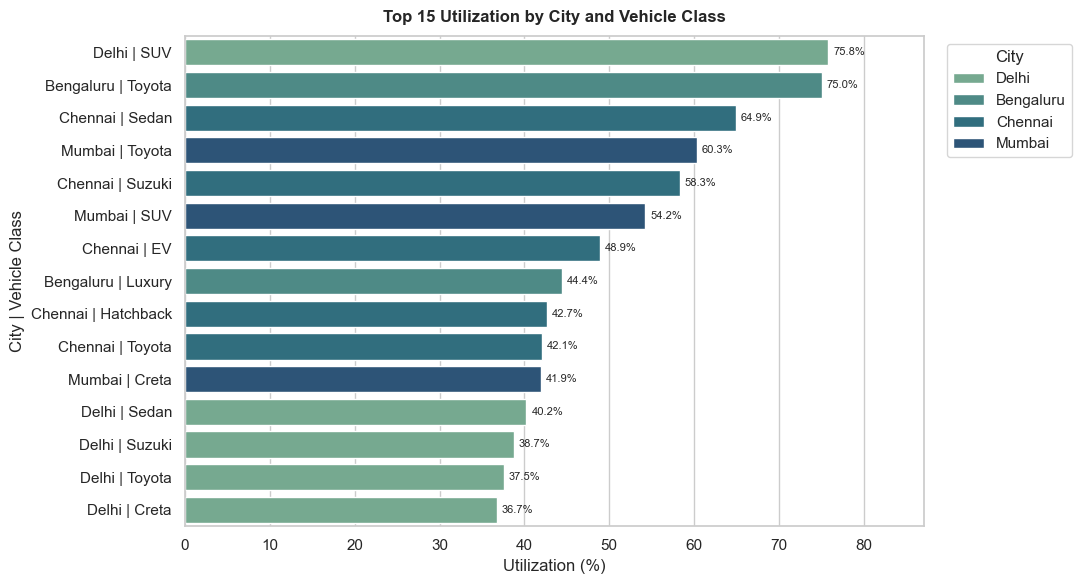

In [48]:
vehicle_activity = df.groupby("Vehicle_ID").agg(
    first_use=("Pickup_TS", "min"),
    last_use=("Return_TS", "max"),
    City=("City", "first"),
    Vehicle_Class=("Vehicle_Class", "first")
).reset_index()

vehicle_activity["active_hours"] = (
    vehicle_activity["last_use"] - vehicle_activity["first_use"]
).dt.total_seconds() / 3600

fleet = vehicle_activity.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    available_cars=("Vehicle_ID", "nunique"),
    fleet_hours=("active_hours", "sum")
)

rental = df.loc[df["is_completed"]].groupby(
    ["City", "Vehicle_Class"], dropna=False
)["rental_hours"].sum().rename("rental_hours")

util = pd.concat([fleet, rental], axis=1).fillna(0).reset_index()

util["utilization"] = np.where(
    util["fleet_hours"] > 0,
    util["rental_hours"] / util["fleet_hours"],
    0
)

util = util.sort_values("utilization", ascending=False)

print(util.head(12))

top_util = util.head(15).copy()
top_util["utilization_pct"] = (top_util["utilization"] * 100).round(2)
top_util["segment"] = top_util["City"].astype(str) + " | " + top_util["Vehicle_Class"].astype(str)
top_util = top_util.sort_values("utilization_pct", ascending=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=top_util,
    x="utilization_pct",
    y="segment",
    hue="City",
    palette="crest",
    dodge=False,
)
ax.set_title("Top 15 Utilization by City and Vehicle Class", pad=10, weight="bold")
ax.set_xlabel("Utilization (%)")
ax.set_ylabel("City | Vehicle Class")

for i, v in enumerate(top_util["utilization_pct"]):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=8)

ax.set_xlim(0, max(top_util["utilization_pct"].max() * 1.15, 5))
ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

## 2) Revenue per available car (RevPAC) and yield metrics


In [49]:
completed = df[df["is_completed"]].copy()

metrics = completed.groupby(["City","Vehicle_Class"], dropna=False).agg(
    total_revenue=("Total_Amount","sum"),
    rental_hours=("rental_hours","sum")
).reset_index()

rev_metrics = util[["City","Vehicle_Class","available_cars"]].merge(
    metrics,
    on=["City","Vehicle_Class"],
    how="left"
).fillna(0)

rev_metrics["RevPAC"] = rev_metrics["total_revenue"] / rev_metrics["available_cars"]

rev_metrics["yield_per_hour"] = rev_metrics["total_revenue"] / rev_metrics["rental_hours"]

pd.options.display.float_format = "{:,.2f}".format

result = rev_metrics[
    ["City","Vehicle_Class","available_cars","total_revenue","RevPAC","yield_per_hour"]
].sort_values("RevPAC", ascending=False)

print(result.head(12))

         City Vehicle_Class  available_cars  total_revenue    RevPAC  \
0       Delhi           SUV              13     145,779.68 11,213.82   
4     Chennai        Suzuki               9      71,203.06  7,911.45   
1   Bengaluru        Toyota              10      78,188.66  7,818.87   
6     Chennai            EV               9      64,429.24  7,158.80   
12      Delhi        Suzuki              19     125,812.84  6,621.73   
9     Chennai        Toyota              13      82,107.50  6,315.96   
10     Mumbai         Creta              18     113,094.92  6,283.05   
2     Chennai         Sedan              15      94,165.24  6,277.68   
19      Delhi     Hatchback              27     160,812.88  5,956.03   
7   Bengaluru        Luxury              17      97,871.68  5,757.16   
30     Mumbai            EV              15      83,119.82  5,541.32   
3      Mumbai        Toyota              17      92,304.56  5,429.68   

    yield_per_hour  
0             2.52  
4             2.18  


## 3) Distance driven and cost per km


         City Vehicle_Class  total_distance_km  cost_per_km  trips
0   Bengaluru         Creta           8,746.00        23.91     44
1   Bengaluru            EV           7,544.00        21.07     36
2   Bengaluru     Hatchback           9,160.00        19.09     42
3   Bengaluru        Luxury          11,324.00        16.71     44
4   Bengaluru           SUV           7,488.00        21.02     38
5   Bengaluru         Sedan          11,066.00        15.28     38
6   Bengaluru        Suzuki           8,887.00        20.43     45
7   Bengaluru        Toyota           7,932.00        21.82     34
8     Chennai         Creta           6,678.00        23.65     31
9     Chennai            EV           6,209.00        21.17     30
10    Chennai     Hatchback           6,616.00        25.14     36
11    Chennai        Luxury           9,446.00        19.73     35
12    Chennai           SUV           5,536.00        15.71     24
13    Chennai         Sedan           8,567.00        19.92   

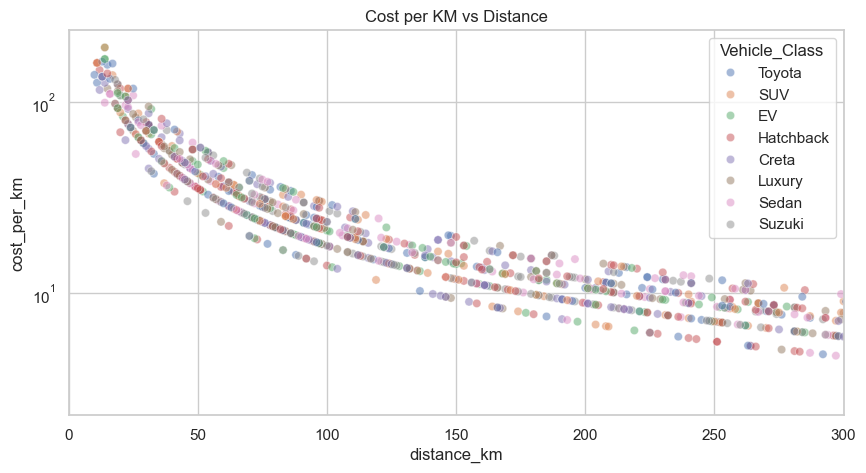

In [50]:
min_distance_km = 10

# Filter valid trips
trip = df[
    (df["is_completed"]) &
    (df["distance_km"] >= min_distance_km) &
    (df["Total_Amount"] > 0)
].copy()

# Cost per km
trip["cost_per_km"] = trip["Total_Amount"] / trip["distance_km"]

# Remove extreme outliers (top 1%)
trip = trip[
    (trip["distance_km"] <= trip["distance_km"].quantile(0.99)) &
    (trip["cost_per_km"] <= trip["cost_per_km"].quantile(0.99))
]

# Aggregated metrics
distance_cost = trip.groupby(["City", "Vehicle_Class"]).agg(
    total_distance_km=("distance_km", "sum"),
    cost_per_km=("cost_per_km", "mean"),
    trips=("Reservation_ID", "count")
).reset_index()

print(distance_cost.head(20))

# Plot
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=trip.sample(min(len(trip), 2000), random_state=42),
    x="distance_km",
    y="cost_per_km",
    hue="Vehicle_Class",
    alpha=0.5
)

plt.yscale("log")
plt.title("Cost per KM vs Distance")
plt.xlabel("distance_km")
plt.ylabel("cost_per_km")
plt.xlim(0, 300)
plt.show()

## 4) Idle time and repositioning analytics


In [51]:
# sort trips by vehicle and pickup time
seq = df.sort_values(["Vehicle_ID", "Pickup_TS"])

# get previous trip return time and city for the same vehicle
seq["prev_return_ts"] = seq.groupby("Vehicle_ID")["Return_TS"].shift()
seq["prev_city"] = seq.groupby("Vehicle_ID")["City"].shift()

# calculate idle time between trips
seq["idle_hours"] = (seq["Pickup_TS"] - seq["prev_return_ts"]).dt.total_seconds() / 3600
seq["idle_hours"] = seq["idle_hours"].clip(lower=0)

# check if vehicle moved to a different city
seq["repositioned"] = (seq["City"] != seq["prev_city"]) & seq["prev_city"].notna()

# summarize idle behaviour per vehicle
idle_summary = seq.groupby("Vehicle_ID").agg(
    avg_idle_hours=("idle_hours", "mean"),
    median_idle_hours=("idle_hours", "median"),
    reposition_events=("repositioned", "sum")
).reset_index()

# show vehicles with highest idle time
print(idle_summary.sort_values("avg_idle_hours", ascending=False).head(10))
print(idle_summary.shape)


    Vehicle_ID  avg_idle_hours  median_idle_hours  reposition_events
117    CAR-118        4,095.25           4,095.25                  1
33     CAR-035        2,764.74           2,764.74                  2
547    CAR-548        2,596.97           2,596.97                  1
147    CAR-148        2,518.46           2,938.02                  1
288    CAR-289        2,489.95           2,489.95                  1
115    CAR-116        2,465.28           2,465.28                  1
340    CAR-341        2,287.82           2,287.82                  0
130    CAR-131        2,090.07           2,090.07                  0
370    CAR-371        1,929.98           1,929.98                  1
395    CAR-396        1,828.80             814.46                  3
(600, 4)


## 5) Dynamic pricing features (demand, lead time, seasonality)


  Reservation_ID     City Vehicle_Class     Rate  lead_time_hours  \
0      RES-00003    Delhi        Suzuki 2,000.00            24.00   
1      RES-03655   Mumbai        Suzuki 2,300.00            24.00   
2      RES-01774   Mumbai        Suzuki 1,840.00            48.00   
3      RES-03809  Chennai        Suzuki 2,000.00           216.00   
4      RES-01293   Mumbai        Suzuki 1,500.00         2,952.00   
5      RES-02593    Delhi        Suzuki 2,300.00         1,488.00   
6      RES-01461    Delhi        Toyota 1,835.27           216.00   
7      RES-02265   Mumbai        Toyota 2,000.00           216.00   
8      RES-03309   Mumbai        Toyota 1,500.00            24.00   
9      RES-02194  Chennai        Toyota 1,500.00            24.00   

   daily_demand  month    weekday  
0             4      3     Monday  
1            14      4     Sunday  
2             6      4    Tuesday  
3             4      6   Saturday  
4             1      9     Monday  
5             9      9  

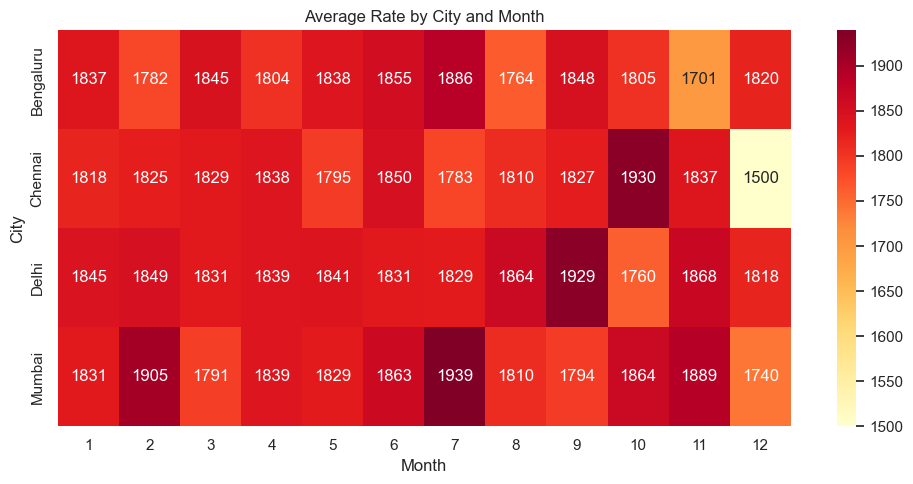

In [52]:
#TRANFORM 5

pricing = df.copy()

pricing["month"] = pricing["Pickup_TS"].dt.month
pricing["weekday"] = pricing["Pickup_TS"].dt.day_name()

pricing["daily_demand"] = pricing.groupby(["City", "pickup_date"])["Reservation_ID"].transform("count")

print(pricing[["Reservation_ID","City","Vehicle_Class","Rate","lead_time_hours","daily_demand","month","weekday"]].head(10))

plt.figure(figsize=(10,5))

heat_data = pricing.pivot_table(
    values="Rate",
    index="City",
    columns="month",
    aggfunc="mean"
)

sns.heatmap(
    heat_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f"
)

plt.title("Average Rate by City and Month")
plt.xlabel("Month")
plt.ylabel("City")

plt.tight_layout()
plt.show()


## 6) Fuel efficiency estimates by model (proxy using Vehicle_Class)


  Vehicle_Class  trips  avg_fuel_efficiency  median_fuel_efficiency
3        Luxury    163             1,166.27                  498.67
6        Suzuki    181             1,162.61                  426.00
0         Creta    210             1,054.67                  462.65
7        Toyota    191               972.36                  460.00
5         Sedan    191               905.45                  424.29
2     Hatchback    212               811.67                  397.33
4           SUV    171               791.95                  416.00
1            EV    165               733.64                  369.39


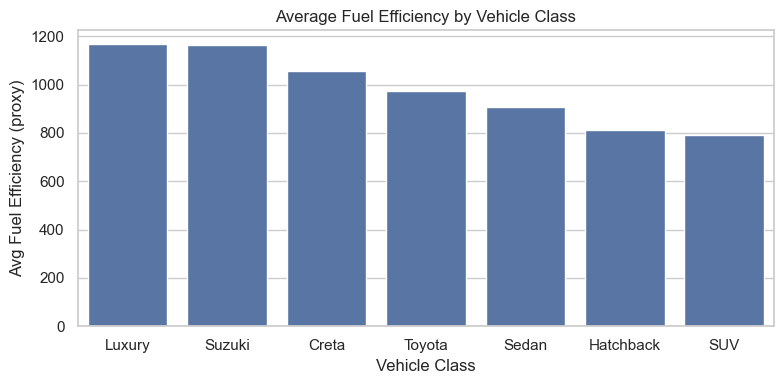

In [53]:
fuel = df[(df["is_completed"]) & (df["distance_km"] > 0)].copy()

fuel["fuel_used_proxy"] = (
    1 - fuel["Fuel_Level"].fillna(fuel["Fuel_Level"].median())
).clip(0.05, 1)

fuel["fuel_efficiency_proxy"] = fuel["distance_km"] / fuel["fuel_used_proxy"]

fuel_eff = fuel.groupby("Vehicle_Class", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_fuel_efficiency=("fuel_efficiency_proxy", "mean"),
    median_fuel_efficiency=("fuel_efficiency_proxy", "median")
).round(2).reset_index().sort_values("avg_fuel_efficiency", ascending=False)

print(fuel_eff)

fuel_eff_plot = fuel_eff[fuel_eff["Vehicle_Class"] != "EV"]
plt.figure(figsize=(8,4))

sns.barplot(
    data=fuel_eff_plot,
    x="Vehicle_Class",
    y="avg_fuel_efficiency"
)

plt.title("Average Fuel Efficiency by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Avg Fuel Efficiency (proxy)")

plt.tight_layout()
plt.show()


## 7) Damage incidence rate per 100 rentals


         City Vehicle_Class  rentals  damage_events  damage_per_100_rentals
7   Bengaluru        Toyota      117             91                   77.78
13    Chennai         Sedan      111             82                   73.87
27     Mumbai        Luxury      108             79                   73.15
1   Bengaluru            EV      128             93                   72.66
29     Mumbai         Sedan      117             84                   71.79
31     Mumbai        Toyota      145            103                   71.03
24     Mumbai         Creta      187            132                   70.59
12    Chennai           SUV       80             56                   70.00
30     Mumbai        Suzuki      129             90                   69.77
14    Chennai        Suzuki       94             65                   69.15


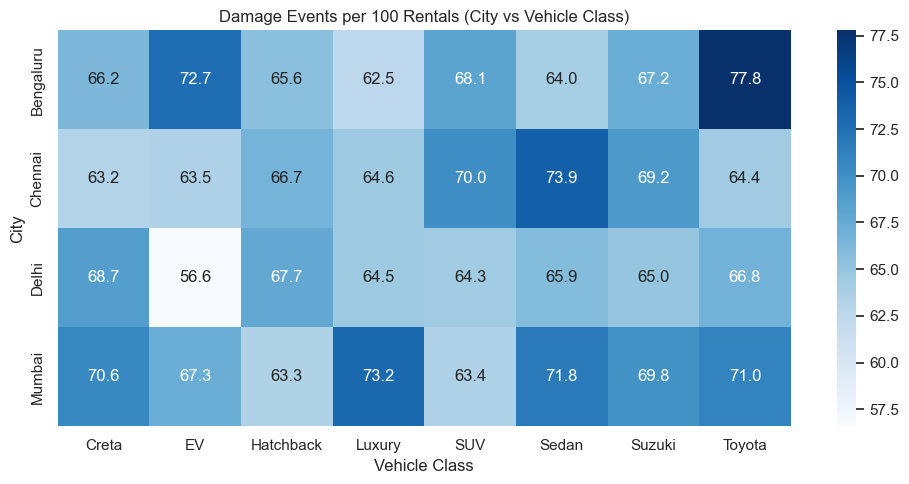

In [54]:
damage = df.copy()

damage["damage_event"] = damage["Damage_Flag"].fillna("None") != "None"

damage_rate = damage.groupby(["City", "Vehicle_Class"]).agg(
    rentals=("Reservation_ID", "count"),
    damage_events=("damage_event", "sum")
).reset_index()

damage_rate["damage_per_100_rentals"] = (
    100 * damage_rate["damage_events"] / damage_rate["rentals"]
).round(2)

print(damage_rate.sort_values("damage_per_100_rentals", ascending=False).head(10))

pivot_damage = damage_rate.pivot(
    index="City",
    columns="Vehicle_Class",
    values="damage_per_100_rentals"
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot_damage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Damage Events per 100 Rentals (City vs Vehicle Class)")
plt.xlabel("Vehicle Class")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## 8) Customer cohort retention and NPS rollups


In [55]:
cust = df[df["is_completed"]].copy()
cust["booking_month_period"] = cust["Booking_TS"].dt.to_period("M")
cohort_month = cust.groupby("Customer_ID")["booking_month_period"].min().rename("cohort_month")
cust = cust.join(cohort_month, on="Customer_ID")

valid = cust.dropna(subset=["booking_month_period", "cohort_month"]).copy()
valid["cohort_index"] = valid["booking_month_period"].astype(int) - valid["cohort_month"].astype(int)

ret_counts = valid.groupby(["cohort_month", "cohort_index"])["Customer_ID"].nunique().unstack(fill_value=0)
if not ret_counts.empty:
    base = ret_counts.iloc[:, 0]
    retention = ret_counts.div(base, axis=0).round(3)
    print("Retention matrix (first rows):")
    print(retention.head())
else:
    print("Retention matrix unavailable (insufficient date data).")

valid["nps_bucket"] = np.select(
    [
        (valid["Driver_Behavior"].eq("Normal Driving") & valid["Damage_Flag"].eq("None")),
        (valid["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | valid["Damage_Flag"].eq("Major")),
    ],
    ["Promoter", "Detractor"],
    default="Passive",
)

nps_rollup = valid.groupby("cohort_month")["nps_bucket"].value_counts(normalize=True).unstack(fill_value=0)
nps_rollup["NPS"] = (nps_rollup.get("Promoter", 0) - nps_rollup.get("Detractor", 0)) * 100
print("\nNPS by cohort month:")
print(nps_rollup[[c for c in ["Promoter", "Passive", "Detractor", "NPS"] if c in nps_rollup.columns]].head(12))


Retention matrix (first rows):
cohort_index   0    1    2    3    4    5    6    7    8    9    10
cohort_month                                                       
2024-12      1.00 0.07 0.09 0.11 0.07 0.11 0.04 0.00 0.00 0.00 0.02
2025-01      1.00 0.09 0.12 0.09 0.10 0.10 0.01 0.00 0.00 0.00 0.00
2025-02      1.00 0.15 0.13 0.11 0.08 0.00 0.00 0.01 0.01 0.01 0.00
2025-03      1.00 0.08 0.07 0.11 0.01 0.00 0.00 0.00 0.00 0.00 0.00
2025-04      1.00 0.09 0.07 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00

NPS by cohort month:
nps_bucket    Passive  Detractor     NPS
cohort_month                            
2024-12          0.31       0.69  -69.01
2025-01          0.30       0.70  -69.82
2025-02          0.32       0.68  -68.34
2025-03          0.39       0.61  -60.67
2025-04          0.31       0.69  -68.64
2025-05          0.31       0.69  -68.70
2025-06          0.35       0.65  -64.77
2025-07          0.40       0.60  -60.00
2025-08          0.60       0.40  -40.00
2025-09          0.2

## 9) Fraud risk score (short returns, odometer anomalies)


In [56]:
#TRANSFORM 9 --> Fraud risk score (short returns, odometer anomalies).

fraud = df.copy()

# Flag 1: Short rental return (completed trips less than 2 hours)
# Simplified condition but logic remains the same
fraud["short_return_flag"] = (fraud["is_completed"]) & (fraud["rental_hours"] < 2)

# Odometer difference
# Created once so it can be reused in anomaly detection
fraud["odo_diff"] = fraud["Odo_End"] - fraud["Odo_Start"]

# Flag 2: Odometer anomaly
# Detect if odometer decreases OR mismatch with recorded distance
fraud["odo_anomaly_flag"] = (fraud["odo_diff"] < 0) | ((fraud["odo_diff"] - fraud["distance_km"]).abs() > 50)

# Flag 3: Speed risk
# Simple threshold rule for abnormal driving speed
fraud["speed_risk_flag"] = fraud["Speed"] > 120

# Fraud risk score
# Weights assigned based on severity of anomaly
fraud["fraud_risk_score"] = (
    30 * fraud["short_return_flag"].astype(int) +     # short return risk
    50 * fraud["odo_anomaly_flag"].fillna(False).astype(int) +   # major anomaly
    20 * fraud["speed_risk_flag"].fillna(False).astype(int) +    # overspeeding
    20 * fraud["vehicle_id_invalid_flag"].astype(int)            # invalid vehicle ID
).clip(0, 100)   # keep score within 0–100

# Final fraud monitoring view
# Selected only relevant columns for easier inspection
fraud_view = fraud[["Reservation_ID","Customer_ID","Vehicle_ID","City","fraud_risk_score","short_return_flag","odo_anomaly_flag","speed_risk_flag","vehicle_id_invalid_flag"]]

# Show highest risk reservations
print(fraud_view.sort_values("fraud_risk_score", ascending=False).head(20))

     Reservation_ID Customer_ID Vehicle_ID       City  fraud_risk_score  \
1638      RES-02411   CUST-1091    CAR-221     Mumbai                50   
1179      RES-00705   CUST-1275    CAR-161  Bengaluru                50   
162       RES-00587   CUST-0711    CAR-022     Mumbai                50   
65        RES-04387   CUST-0081    CAR-010      Delhi                50   
2761      RES-02492   CUST-1845    CAR-368      Delhi                50   
2906      RES-03534   CUST-0054    CAR-388    Chennai                50   
207       RES-02627   CUST-1521    CAR-027     Mumbai                50   
2469      RES-02750   CUST-0798    CAR-334  Bengaluru                50   
3044      RES-02534   CUST-1429    CAR-407     Mumbai                50   
4515      RES-01041   CUST-0416    CAR-600    Chennai                40   
4520      RES-00590   CUST-1291    CAR-600      Delhi                40   
4517      RES-03681   CUST-1584    CAR-600     Mumbai                40   
1521      RES-02088   CUS

## 10) Maintenance due forecast (km/time based)


In [57]:
# Filter to Completed trips only — odometer readings are only meaningful here
df_completed = df[df["Booking_Status"] == "Completed"]

latest = (
    df_completed
    .sort_values("Return_TS")
    .groupby("Vehicle_ID", as_index=False)
    .tail(1)
    .copy()
)

latest["current_odometer"] = latest["Odo_End"].fillna(latest["Odo_Start"])
latest["km_to_next_service"] = 10000 - (latest["current_odometer"] % 10000)
latest["days_since_last_return"] = (
    pd.Timestamp.today().normalize() - latest["Return_TS"]
).dt.days

latest["maintenance_due"] = (
    (latest["km_to_next_service"] <= 500) | (latest["days_since_last_return"] >= 180)
)

# Fix: clip days score at 1, not 2, so final score stays in [0, 1]
latest["maintenance_priority"] = (
    ((500 - latest["km_to_next_service"]).clip(lower=0) / 500) * 0.6
    + (latest["days_since_last_return"].clip(lower=0) / 180).clip(upper=1) * 0.4
)

print(
    latest[[
        "Vehicle_ID", "Vehicle_Class", "current_odometer",
        "km_to_next_service", "days_since_last_return",
        "maintenance_due", "maintenance_priority"
    ]]
    .sort_values(["maintenance_due", "maintenance_priority"], ascending=[False, False])
    .head(20)
)

     Vehicle_ID Vehicle_Class  current_odometer  km_to_next_service  \
1257    CAR-173        Suzuki         59,935.00               65.00   
1361    CAR-186        Toyota         69,928.00               72.00   
4378    CAR-582        Suzuki         59,910.00               90.00   
4267    CAR-567         Sedan         49,894.00              106.00   
1106    CAR-153        Toyota         49,870.00              130.00   
4128    CAR-552         Sedan         59,864.00              136.00   
1519    CAR-207     Hatchback         59,952.00               48.00   
3446    CAR-463        Suzuki         69,911.00               89.00   
403     CAR-051         Creta         29,956.00               44.00   
4027    CAR-539         Creta         29,809.00              191.00   
3640    CAR-489        Luxury         19,801.00              199.00   
4063    CAR-544         Creta         29,769.00              231.00   
1368    CAR-187            EV         69,767.00              233.00   
2506  

## 11) Overstay detection and penalty calculation


In [58]:
overstay = df[df["is_completed"]].copy()
overstay = overstay[(overstay["Rate"] > 0) & overstay["rental_hours"].notna()].copy()

# Rate is daily in this dataset; convert to hourly basis for penalties
overstay["hourly_rate"] = overstay["Rate"] / 24

# Bill-derived expected hours (fallback to 24h package when billing is synthetic)
overstay["expected_hours_from_bill"] = ((overstay["Total_Amount"] / 1.18) / overstay["Rate"]) * 24
overstay["expected_hours_from_bill"] = (
    overstay["expected_hours_from_bill"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(24)
    .clip(lower=4, upper=72)
)

grace_hours = 2
overstay["overstay_hours"] = (
    overstay["rental_hours"] - overstay["expected_hours_from_bill"] - grace_hours
).clip(lower=0)

# Split normal cases vs anomalous long durations
max_auto_bill_hours = 240  # >10 days should be manually investigated
overstay["manual_review_flag"] = overstay["rental_hours"] > max_auto_bill_hours

# Cap billable overstay for automatic penalty calculation
overstay["overstay_hours_capped"] = overstay["overstay_hours"].clip(upper=72)
h = overstay["overstay_hours_capped"]

overstay["penalty_first_6h"] = np.minimum(h, 6) * 0.25 * overstay["hourly_rate"]
overstay["penalty_next_18h"] = np.minimum(np.clip(h - 6, 0, None), 18) * 0.50 * overstay["hourly_rate"]
overstay["penalty_after_24h"] = np.clip(h - 24, 0, None) * 1.00 * overstay["hourly_rate"]

overstay["overstay_penalty"] = (
    overstay["penalty_first_6h"]
    + overstay["penalty_next_18h"]
    + overstay["penalty_after_24h"]
)

# Final hard cap: penalty cannot exceed 125% of one-day rate
overstay["overstay_penalty"] = np.minimum(overstay["overstay_penalty"], overstay["Rate"] * 1.25)

# Do not auto-penalize anomalous records; escalate for manual review
overstay.loc[overstay["manual_review_flag"], "overstay_penalty"] = np.nan

print(f"Manual review rows: {overstay['manual_review_flag'].sum():,} / {len(overstay):,}")
print(overstay[[
    "Reservation_ID", "City", "expected_hours_from_bill",
    "overstay_hours", "overstay_penalty", "manual_review_flag"
]].sort_values("overstay_penalty", ascending=False, na_position="last").head(20))

Manual review rows: 551 / 1,487
     Reservation_ID       City  expected_hours_from_bill  overstay_hours  \
3914      RES-03224     Mumbai                     24.00           45.00   
1441      RES-02189      Delhi                     24.00           43.00   
993       RES-04323    Chennai                     24.00           43.00   
730       RES-03698      Delhi                     24.00           42.00   
35        RES-03934  Bengaluru                     24.00           42.95   
2840      RES-03019      Delhi                     24.00           42.00   
2851      RES-02699  Bengaluru                     24.00           39.00   
4023      RES-03182      Delhi                     24.00           40.00   
2594      RES-04411      Delhi                     24.00           40.00   
864       RES-03862     Mumbai                     24.00           39.87   
0         RES-00003      Delhi                     24.00           45.00   
3361      RES-02873  Bengaluru                     24.00

## 12) Pickup/return punctuality stats


Assumptions for punctuality (proxy):
- `scheduled_pickup = Booking_TS + 24 hours` is only meaningful for short lead-time bookings.
- Therefore, pickup punctuality is computed on completed bookings with `0 <= lead_time_hours <= 48` (`pickup_proxy_eligible=True`).
- Pickup on-time threshold: `|pickup_delay_min| <= 30` minutes.
- Return punctuality is measured by difference between computed actual duration and provided `Duration_Hours` field (`|return_delay_min| <= 30`).
- Reported average delays are clipped means (1st-99th percentile) to reduce outlier distortion; medians are also shown.


In [59]:
punct = df[df["is_completed"]].copy()
punct = punct.dropna(subset=["Booking_TS", "Pickup_TS", "Return_TS"])

punct["lead_time_hours"] = (punct["Pickup_TS"] - punct["Booking_TS"]).dt.total_seconds() / 3600

# Keep only bookings where the 24h scheduled pickup proxy is plausible.
pickup_proxy_max_lead_hours = 48
punct["pickup_proxy_eligible"] = punct["lead_time_hours"].between(0, pickup_proxy_max_lead_hours)

pickup_eval = punct[punct["pickup_proxy_eligible"]].copy()
pickup_eval["scheduled_pickup"] = pickup_eval["Booking_TS"] + pd.Timedelta(hours=24)
pickup_eval["pickup_delay_min"] = (pickup_eval["Pickup_TS"] - pickup_eval["scheduled_pickup"]).dt.total_seconds() / 60
pickup_eval["pickup_on_time"] = pickup_eval["pickup_delay_min"].abs() <= 30

pickup_lo, pickup_hi = pickup_eval["pickup_delay_min"].quantile([0.01, 0.99])
pickup_eval["pickup_delay_min_clipped"] = pickup_eval["pickup_delay_min"].clip(pickup_lo, pickup_hi)

pickup_stats = pickup_eval.groupby("City", dropna=False).agg(
    pickup_rows=("Reservation_ID", "count"),
    pickup_on_time_rate=("pickup_on_time", "mean"),
    avg_pickup_delay_min=("pickup_delay_min_clipped", "mean"),
    median_pickup_delay_min=("pickup_delay_min", "median"),
).reset_index()

# Return punctuality can be measured for all completed trips with valid duration fields.
punct["actual_duration_hours"] = (punct["Return_TS"] - punct["Pickup_TS"]).dt.total_seconds() / 3600
punct["return_delay_min"] = (punct["actual_duration_hours"] - punct["Duration_Hours"]) * 60
punct["return_delay_min"] = punct["return_delay_min"].replace([np.inf, -np.inf], np.nan)
punct["return_on_time"] = punct["return_delay_min"].abs() <= 30

return_lo, return_hi = punct["return_delay_min"].quantile([0.01, 0.99])
punct["return_delay_min_clipped"] = punct["return_delay_min"].clip(return_lo, return_hi)

return_stats = punct.groupby("City", dropna=False).agg(
    return_rows=("Reservation_ID", "count"),
    return_on_time_rate=("return_on_time", "mean"),
    avg_return_delay_min=("return_delay_min_clipped", "mean"),
    median_return_delay_min=("return_delay_min", "median"),
).reset_index()

city_total = punct.groupby("City", dropna=False)["Reservation_ID"].count().rename("completed_rows").reset_index()

punct_stats = (
    city_total
    .merge(pickup_stats, on="City", how="left")
    .merge(return_stats, on="City", how="left")
)

punct_stats["pickup_metric_coverage_pct"] = (100 * punct_stats["pickup_rows"].fillna(0) / punct_stats["completed_rows"]).round(2)
punct_stats["pickup_on_time_rate"] = (punct_stats["pickup_on_time_rate"] * 100).round(2)
punct_stats["return_on_time_rate"] = (punct_stats["return_on_time_rate"] * 100).round(2)

# Keep only the most important columns for compact output.
punct_view = punct_stats[[
    "City",
    "pickup_on_time_rate",
    "return_on_time_rate",
    "avg_pickup_delay_min",
    "avg_return_delay_min",
    "pickup_metric_coverage_pct",
]].round(2)

# Render as a horizontally scrollable output block in notebook.
from IPython.display import HTML, display
table_html = punct_view.to_html(index=False)
display(HTML(
    "<div style='max-height:320px; overflow:auto; border:1px solid #ddd; padding:8px;'>" + table_html + "</div>"
))

City,pickup_on_time_rate,return_on_time_rate,avg_pickup_delay_min,avg_return_delay_min,pickup_metric_coverage_pct
Bengaluru,87.88,98.24,129.39,0.01,38.82
Chennai,85.44,100.00,147.00,-0.00,36.79
Delhi,91.71,100.00,78.48,-0.00,41.25
Mumbai,83.61,99.41,220.65,0.00,35.78


## 13) Geo heatmaps of pickup/drop hotspots


Drop coordinates are not separately available; pickup geo points are used as hotspot proxy.


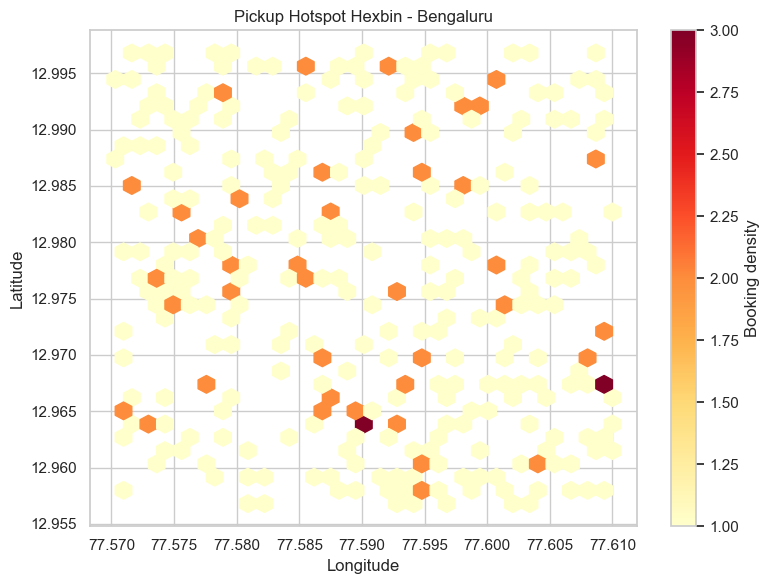

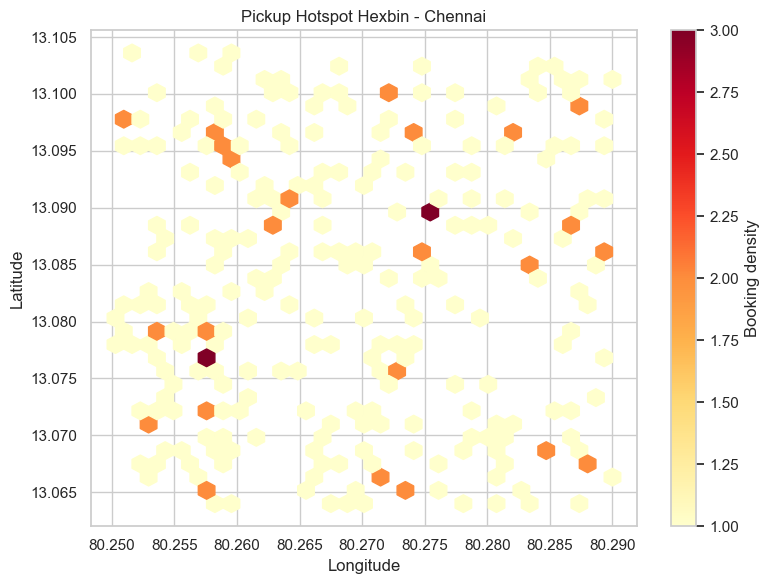

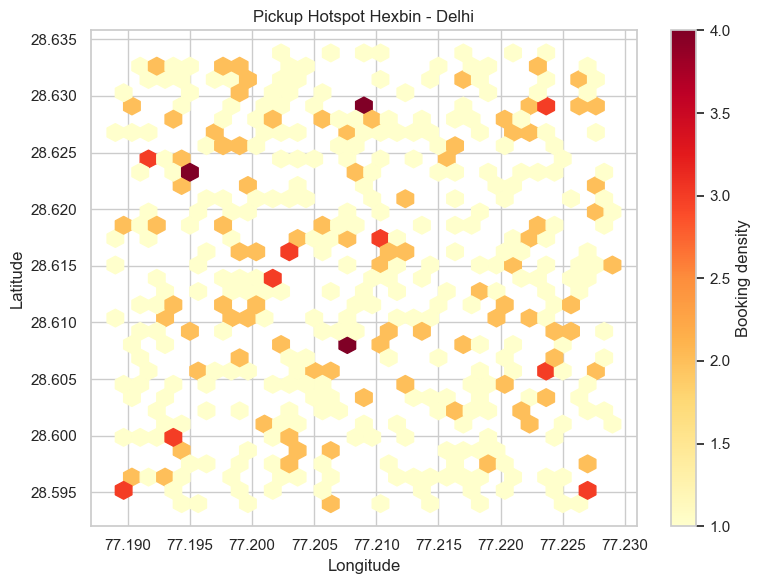

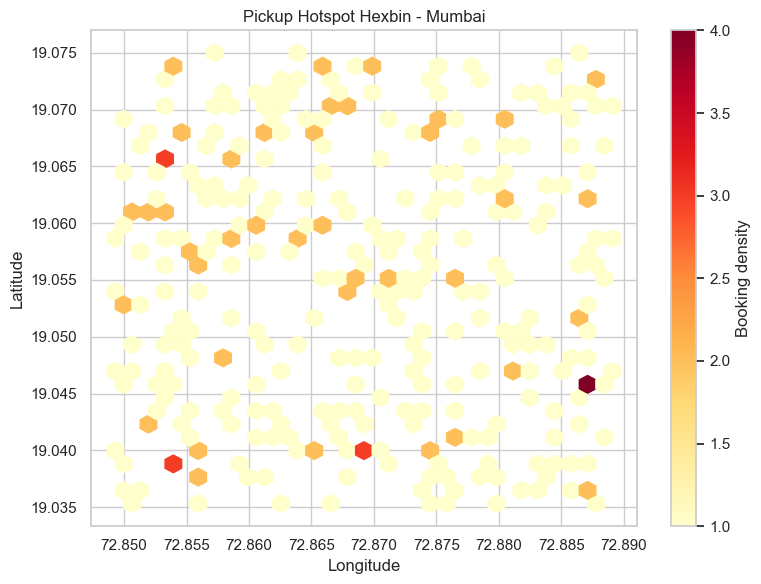

         City  lat_bin  lon_bin  bookings
57      Delhi    28.60    77.22        37
70      Delhi    28.63    77.20        37
60      Delhi    28.61    77.20        36
72      Delhi    28.63    77.22        34
62      Delhi    28.61    77.22        33
65      Delhi    28.62    77.20        33
66      Delhi    28.62    77.21        33
61      Delhi    28.61    77.21        32
67      Delhi    28.62    77.22        31
71      Delhi    28.63    77.21        30
55      Delhi    28.60    77.20        29
11  Bengaluru    12.98    77.58        28
85     Mumbai    19.06    72.86        26
3   Bengaluru    12.96    77.60        25
2   Bengaluru    12.96    77.59        25


In [60]:
geo = df[df["is_completed"]].dropna(subset=["GPS_Lat", "GPS_Lon"]).copy()

# Heatmap per city
for city, data in geo.groupby("City"):

    plt.figure(figsize=(8, 6))
    plt.hexbin(data["GPS_Lon"], data["GPS_Lat"], gridsize=30, cmap="YlOrRd", mincnt=1)
    plt.colorbar(label="Booking density")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Pickup Hotspot Hexbin - {city}")

    plt.tight_layout()
    plt.show()


# Identify hotspot zones
hotspots = (
    geo.assign(
        lat_bin=geo["GPS_Lat"].round(2),
        lon_bin=geo["GPS_Lon"].round(2)
    )
    .groupby(["City", "lat_bin", "lon_bin"], dropna=False)
    .size()
    .reset_index(name="bookings")
    .sort_values("bookings", ascending=False)
)

print(hotspots.head(15))

## 14) Upsell/cross-sell opportunity flags (addons)


In [61]:
upsell = df.copy()
notes = upsell["Notes"].fillna("").str.lower()

upsell["addon_navigation"] = notes.str.contains("navigation")
upsell["addon_cleaning"] = notes.str.contains("clean")
upsell["addon_fuel_plan"] = notes.str.contains("fuel") | (upsell["Fuel_Level"].fillna(0.5) < 0.25)
upsell["addon_protection"] = upsell["Driver_Behavior"].isin(["Speeding", "Fast Driving"]) | upsell["Damage_Flag"].isin(["Minor", "Major"])

flag_cols = ["addon_navigation", "addon_cleaning", "addon_fuel_plan", "addon_protection"]
upsell["upsell_flag_count"] = upsell[flag_cols].sum(axis=1)
upsell["upsell_opportunity"] = upsell["upsell_flag_count"] > 0

upsell_summary = upsell.groupby("City", dropna=False).agg(
    rentals=("Reservation_ID", "count"),
    opportunities=("upsell_opportunity", "sum"),
).reset_index()
upsell_summary["opportunity_rate"] = 100 * upsell_summary["opportunities"] / upsell_summary["rentals"]

print(upsell_summary.sort_values("opportunity_rate", ascending=False))


        City  rentals  opportunities  opportunity_rate
3     Mumbai     1061            953             89.82
1    Chennai      798            714             89.47
2      Delhi     1627           1443             88.69
0  Bengaluru     1041            920             88.38


## 15) Cancellation rate and reasons analysis


In [62]:
cancel = df.copy()
cancel["is_cancelled"] = cancel["Booking_Status"].isin(["Cancelled", "No_Show"])
notes = cancel["Notes"].fillna("").str.lower()

cancel["cancel_reason_bucket"] = np.select(
    [
        notes.str.contains("traffic"),
        notes.str.contains("fuel"),
        notes.str.contains("clean"),
        notes.str.contains("scratch|damage"),
        notes.str.contains("early pickup"),
        notes.str.contains("no notes"),
    ],
    ["Traffic", "Fuel", "Cleaning", "Damage Concern", "Schedule Change", "Unspecified"],
    default="Other",
)

cancel_rate = cancel.groupby(["City", "Vehicle_Class"], dropna=False).agg(
    total_bookings=("Reservation_ID", "count"),
    cancelled=("is_cancelled", "sum"),
).reset_index()
cancel_rate["cancellation_rate"] = 100 * cancel_rate["cancelled"] / cancel_rate["total_bookings"]

reason_dist = cancel[cancel["is_cancelled"]].groupby("cancel_reason_bucket").size().reset_index(name="count").sort_values("count", ascending=False)

print(cancel_rate.sort_values("cancellation_rate", ascending=False).head(12))
print("\nCancellation reason distribution:")
print(reason_dist)


         City Vehicle_Class  total_bookings  cancelled  cancellation_rate
19      Delhi        Luxury             189        139              73.54
5   Bengaluru         Sedan             136         96              70.59
24     Mumbai         Creta             187        132              70.59
22      Delhi        Suzuki             200        141              70.50
27     Mumbai        Luxury             108         76              70.37
1   Bengaluru            EV             128         90              70.31
2   Bengaluru     Hatchback             151        106              70.20
29     Mumbai         Sedan             117         82              70.09
12    Chennai           SUV              80         56              70.00
31     Mumbai        Toyota             145        100              68.97
8     Chennai         Creta             106         73              68.87
0   Bengaluru         Creta             154        106              68.83

Cancellation reason distribution:
  c

## 16) Driver behavior scoring from telematics


In [63]:
driver = df.copy()
driver["driver_score"] = 100

driver["driver_score"] = driver["driver_score"] - np.where(driver["Speed"] > 120, 30, np.where(driver["Speed"] > 100, 15, 0))
driver["driver_score"] = driver["driver_score"] - np.where(driver["Driver_Behavior"].eq("Speeding"), 25, np.where(driver["Driver_Behavior"].eq("Fast Driving"), 10, 0))
driver["driver_score"] = driver["driver_score"] - np.where(driver["Damage_Flag"].eq("Major"), 20, np.where(driver["Damage_Flag"].eq("Minor"), 8, 0))
driver["driver_score"] = driver["driver_score"].clip(lower=0, upper=100)

driver_summary = driver.groupby("Customer_ID", dropna=False).agg(
    trips=("Reservation_ID", "count"),
    avg_driver_score=("driver_score", "mean"),
).reset_index().sort_values("avg_driver_score")

print(driver_summary.head(20))


     Customer_ID  trips  avg_driver_score
1256   CUST-1388      1             25.00
811    CUST-0892      1             25.00
346    CUST-0375      1             25.00
717    CUST-0787      2             25.00
1683   CUST-1858      1             25.00
1673   CUST-1847      1             25.00
1170   CUST-1289      2             25.00
443    CUST-0483      1             25.00
143    CUST-0154      1             25.00
457    CUST-0497      2             25.00
967    CUST-1062      1             25.00
551    CUST-0596      1             25.00
1022   CUST-1126      1             25.00
1071   CUST-1179      1             25.00
596    CUST-0644      1             25.00
1580   CUST-1748      1             25.00
1478   CUST-1636      1             25.00
1276   CUST-1410      1             25.00
1020   CUST-1124      2             31.00
1460   CUST-1616      2             35.00


## 17) Vehicle class mix optimization


In [64]:
mix = util.merge(rev_metrics[["City", "Vehicle_Class", "RevPAC"]], on=["City", "Vehicle_Class"], how="left")
mix["fleet_share"] = mix.groupby("City")["available_cars"].transform(lambda s: s / max(s.sum(), 1))

mix["util_norm"] = mix.groupby("City")["utilization"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["rev_norm"] = mix.groupby("City")["RevPAC"].transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9))
mix["mix_score"] = 0.6 * mix["util_norm"] + 0.4 * mix["rev_norm"]

mix["mix_action"] = np.where(mix["mix_score"] >= 0.66, "Increase share", np.where(mix["mix_score"] >= 0.33, "Hold / optimize", "Reduce share"))

print(mix.sort_values(["City", "mix_score"], ascending=[True, False]))


         City Vehicle_Class  available_cars  fleet_hours  rental_hours  \
1   Bengaluru        Toyota              10    56,872.98     42,669.97   
7   Bengaluru        Luxury              17    95,908.35     42,585.52   
18  Bengaluru           SUV              15    99,447.00     33,577.08   
16  Bengaluru        Suzuki              20   108,762.52     37,669.20   
22  Bengaluru     Hatchback              20   118,916.47     37,369.52   
24  Bengaluru         Sedan              18   106,025.68     29,979.12   
26  Bengaluru            EV              19   110,097.65     28,665.80   
29  Bengaluru         Creta              24   146,412.63     34,010.07   
4     Chennai        Suzuki               9    56,079.77     32,709.91   
2     Chennai         Sedan              15    83,321.07     54,094.13   
6     Chennai            EV               9    56,481.72     27,611.10   
9     Chennai        Toyota              13    79,469.72     33,437.33   
8     Chennai     Hatchback           

## 18) Lead-time price elasticity features


          City Vehicle_Class lead_time_bucket  price_elasticity
53     Chennai        Suzuki              NaN            -44.13
58       Delhi         Creta           Medium            -29.39
35     Chennai     Hatchback           Medium            -14.08
30     Chennai         Creta              NaN            -11.70
24   Bengaluru        Toyota           Medium            -10.52
14   Bengaluru           SUV           Medium             -9.51
76       Delhi         Sedan           Medium             -9.06
114     Mumbai        Toyota           Medium             -8.32
64       Delhi            EV              NaN             -6.60
87      Mumbai         Creta             Long             -5.81
67       Delhi     Hatchback              NaN             -5.71
88      Mumbai         Creta              NaN             -5.00
91      Mumbai            EV             Long             -4.94
6    Bengaluru            EV              NaN             -4.60
69       Delhi        Luxury           M

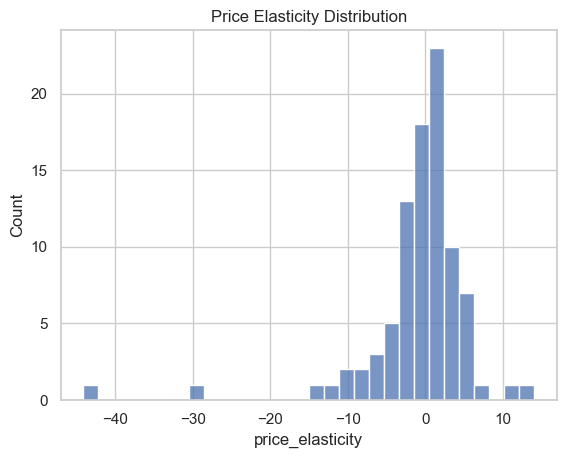

In [65]:
elastic = df.copy()

elastic["week"] = elastic["Booking_TS"].dt.to_period("W").astype(str)

weekly = elastic.groupby(["City", "Vehicle_Class", "week"], dropna=False).agg(
    bookings=("Reservation_ID", "count"),
    avg_rate=("Rate", "mean"),
    avg_lead_time=("lead_time_hours", "mean"),
).reset_index()

# NEW: Lead time segmentation
weekly["lead_time_bucket"] = pd.cut(
    weekly["avg_lead_time"],
    bins=[0, 6, 24, 72, 999],
    labels=["Last_Minute", "Short", "Medium", "Long"],
    include_lowest=True
)

def elasticity_proxy(g):
    g = g[(g["bookings"] > 0) & (g["avg_rate"] > 0)].dropna(subset=["bookings", "avg_rate"])

    if len(g) < 3 or g["avg_rate"].nunique() < 2:
        return np.nan

    x = np.log(g["avg_rate"])
    y = np.log(g["bookings"])

    return np.cov(x, y, bias=True)[0, 1] / (np.var(x) + 1e-9)


# UPDATED GROUPING
elasticity_table = (
    weekly.groupby(["City", "Vehicle_Class", "lead_time_bucket"], dropna=False)
    .apply(elasticity_proxy)
    .reset_index(name="price_elasticity")
)

print(elasticity_table.sort_values("price_elasticity").head(20))


# Visualization
sns.histplot(elasticity_table["price_elasticity"].dropna(), bins=30)
plt.title("Price Elasticity Distribution")
plt.show()

## 19) Fleet health score combining faults and usage


In [66]:
health_src = df.copy()
notes = health_src["Notes"].fillna("").str.lower()

health_src["fault_points"] = (
    np.where(health_src["Damage_Flag"].eq("Major"), 20, 0)
    + np.where(health_src["Damage_Flag"].eq("Minor"), 10, 0)
    + np.where(notes.str.contains("alert|malfunction|scratch"), 8, 0)
)

health_src["usage_hours_component"] = np.where(
    health_src["is_completed"],
    health_src["rental_hours"].fillna(0),
    0
)

health = health_src.groupby(["Vehicle_ID", "Vehicle_Class"], dropna=False).agg(
    fault_points=("fault_points", "sum"),
    usage_hours=("usage_hours_component", "sum"),
    avg_speed=("Speed", "mean"),
    rentals=("Reservation_ID", "count"),
).reset_index()

health["fault_norm"] = health["fault_points"] / (health["fault_points"].max() + 1e-9)
health["usage_norm"] = health["usage_hours"] / (health["usage_hours"].max() + 1e-9)

# UPDATED SPEED NORMALIZATION
max_speed = health["avg_speed"].max()
health["speed_norm"] = (health["avg_speed"].fillna(0) / max_speed).clip(0, 1)

health["fleet_health_score"] = 100 - (
    50 * health["fault_norm"] +
    30 * health["usage_norm"] +
    20 * health["speed_norm"]
)

health["fleet_health_score"] = health["fleet_health_score"].clip(0, 100)

health["health_band"] = pd.cut(
    health["fleet_health_score"],
    bins=[0, 50, 75, 100],
    labels=["Poor", "Moderate", "Healthy"],
    include_lowest=True
)

print(
    health[
        ["Vehicle_ID","Vehicle_Class","fleet_health_score","health_band"]
    ].head(20)
)

   Vehicle_ID Vehicle_Class  fleet_health_score health_band
0     CAR-001        Suzuki               69.81    Moderate
1     CAR-002        Toyota               64.36    Moderate
2     CAR-003     Hatchback               72.01    Moderate
3     CAR-005           SUV               48.21        Poor
4     CAR-006        Luxury               67.15    Moderate
5     CAR-007        Toyota               73.53    Moderate
6     CAR-008     Hatchback               65.27    Moderate
7     CAR-009         Creta               76.64     Healthy
8     CAR-010         Sedan               59.58    Moderate
9     CAR-011        Luxury               70.47    Moderate
10    CAR-012         Creta               54.87    Moderate
11    CAR-013            EV               77.88     Healthy
12    CAR-014     Hatchback               55.51    Moderate
13    CAR-015         Sedan               55.58    Moderate
14    CAR-016        Suzuki               75.67     Healthy
15    CAR-017        Luxury             

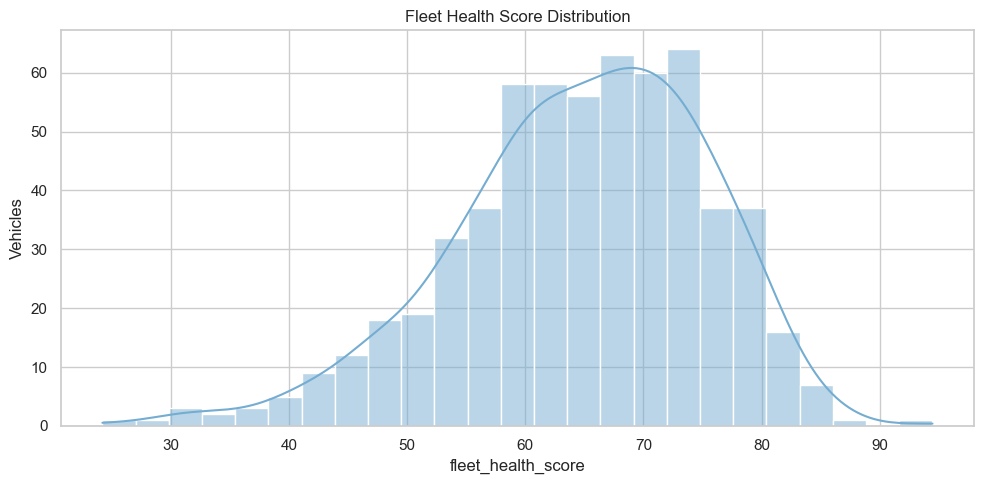

In [67]:
# Visualization: fleet health score distribution
health_plot = health.dropna(subset=["fleet_health_score"]).copy()

if health_plot.empty:
    print("No fleet health records available for plotting.")
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=health_plot, x="fleet_health_score", bins=25, kde=True, color="#74add1")
    plt.title("Fleet Health Score Distribution")
    plt.xlabel("fleet_health_score")
    plt.ylabel("Vehicles")
    plt.tight_layout()
    plt.show()

## 20) Churn likelihood for subscription rentals


Subscription proxy: customers with at least 3 bookings in the dataset are treated as subscription-like customers.


In [68]:
churn_src = df.copy()
churn_src["booking_date"] = churn_src["Booking_TS"].dt.floor("D")

cust_counts = churn_src.groupby("Customer_ID")["Reservation_ID"].count().rename("total_bookings")
subs = cust_counts[cust_counts >= 3].index
sub_df = churn_src[churn_src["Customer_ID"].isin(subs)].copy()

snapshot = sub_df["booking_date"].max() + pd.Timedelta(days=1) if not sub_df.empty else pd.Timestamp.today().normalize()

last_booking = sub_df.groupby("Customer_ID")["booking_date"].max().rename("last_booking")
sub_df["days_ago"] = (snapshot - sub_df["booking_date"]).dt.days

recent_90 = sub_df[sub_df["days_ago"] <= 90].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_recent_90")
prev_90 = sub_df[(sub_df["days_ago"] > 90) & (sub_df["days_ago"] <= 180)].groupby("Customer_ID")["Reservation_ID"].count().rename("bookings_prev_90")

churn = pd.concat([cust_counts, last_booking, recent_90, prev_90], axis=1).fillna(0)
churn = churn.loc[churn.index.isin(subs)].copy()

churn["days_since_last_booking"] = (snapshot - pd.to_datetime(churn["last_booking"])) .dt.days
churn["drop_ratio"] = np.where(churn["bookings_prev_90"] > 0, (churn["bookings_prev_90"] - churn["bookings_recent_90"]) / churn["bookings_prev_90"], 0)

churn["recency_norm"] = (churn["days_since_last_booking"] / 90).clip(0, 1)
churn["drop_norm"] = churn["drop_ratio"].clip(0, 1)
churn["churn_likelihood"] = (0.6 * churn["recency_norm"] + 0.4 * churn["drop_norm"]).clip(0, 1)
churn["churn_band"] = pd.cut(churn["churn_likelihood"], bins=[-0.01, 0.33, 0.66, 1.0], labels=["Low", "Medium", "High"])

print(churn.sort_values("churn_likelihood", ascending=False).head(20))
print("\nChurn Risk Distribution:")
print(churn["churn_band"].value_counts())


             total_bookings         last_booking  bookings_recent_90  \
Customer_ID                                                            
CUST-1997                 4  2025-06-20 00:00:00                0.00   
CUST-0004                 3  2025-06-16 00:00:00                0.00   
CUST-0007                 5  2025-06-24 00:00:00                0.00   
CUST-0008                 3  2025-06-18 00:00:00                0.00   
CUST-0011                 5  2025-06-17 00:00:00                0.00   
CUST-0014                 4  2025-05-23 00:00:00                0.00   
CUST-0015                 3  2025-06-15 00:00:00                0.00   
CUST-0017                 4  2025-06-16 00:00:00                0.00   
CUST-0018                 3  2025-05-16 00:00:00                0.00   
CUST-1957                 5  2025-06-17 00:00:00                0.00   
CUST-1953                 3  2025-07-06 00:00:00                0.00   
CUST-1949                 5  2025-06-18 00:00:00                